# ATML Assignment 5 — Task 1: LLM Decoding Strategy Analysis

This notebook implements:

- Loading the `SmolLM2-135M-SFT-Only` baseline model
- Implementing four decoding strategies from scratch:
  - Greedy Search
  - Beam Search
  - Top-K Sampling
  - Top-P (Nucleus) Sampling
- Running generation over a small instruction dataset (held-out subset) - alpaca
- Computing **Distinct-N** diversity metrics (N = 1, 2, 3)
- Scoring outputs with a **reward model** for quality
- Performing **Across-Prompt** and **Within-Prompt** diversity analyses


In [1]:
%%bash
# Install dependencies (run once per environment)
pip install -q transformers datasets accelerate torch torchvision torchaudio
pip install -q matplotlib
# Example small reward model (adjust if unavailable)
pip install -q sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 33.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pylibcudf-cu12==25.6.*, but you have pylibcudf-cu12 25.2.2 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.

In [2]:
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple

import torch
from torch.nn import functional as F

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    set_seed,
)
from datasets import load_dataset
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# Configuration for Task 1

set_seed(42)

BASE_MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-SFT-Only" # Base SFT model 
REWARD_MODEL_NAME = "OpenAssistant/reward-model-deberta-v3-base" # DeBERTa-based reward model
DATASET_NAME = "tatsu-lab/alpaca"  # alpaca instruction dataset - small subset
DATASET_SPLIT = "train"

# Decoding hyperparameters
MAX_NEW_TOKENS = 128
BEAM_WIDTH = 4
TOP_K = 40
TOP_P = 0.9
TEMPERATURES = [0.2, 0.5, 0.8, 1.0, 1.2]

# Evaluation settings
NUM_PROMPTS_ACROSS = 32  # for Across-Prompt diversity (one sample per prompt)
NUM_SAMPLES_WITHIN = 32  # for Within-Prompt diversity (many samples for one prompt)

print("Config loaded.")

2025-11-22 13:21:37.103338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763817697.273098      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763817697.323903      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Config loaded.


In [4]:
# Load tokenizer and base SFT model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
if tokenizer.pad_token is None:
    # For causal LMs, it's common to set pad_token = eos_token for batching
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME, torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32)
model.to(DEVICE)
model.eval()

eos_token_id = tokenizer.eos_token_id
pad_token_id = tokenizer.pad_token_id

print("Base model and tokenizer loaded.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Base model and tokenizer loaded.


In [5]:
# Load reward model for quality scoring

reward_tokenizer = AutoTokenizer.from_pretrained(REWARD_MODEL_NAME)
reward_model = AutoModelForSequenceClassification.from_pretrained(REWARD_MODEL_NAME)
reward_model.to(DEVICE)
reward_model.eval()

print("Reward model loaded.")

tokenizer_config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/988 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/738M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Reward model loaded.


In [6]:
# Load a small held-out subset of an instruction dataset

raw_ds = load_dataset(DATASET_NAME, split=DATASET_SPLIT)

# For Alpaca-style datasets, fields are often 'instruction', 'input', 'output'
def format_prompt(example: Dict[str, Any]) -> str:
    instr = example.get("instruction", "")
    inp = example.get("input", "")
    if inp:
        return f"Instruction: {instr}\nInput: {inp}\nAnswer:"
    else:
        return f"Instruction: {instr}\nAnswer:"

prompts = [format_prompt(ex) for ex in raw_ds.select(range(200))]  # small pool for experiments
print(f"Prepared {len(prompts)} formatted prompts.")

# Pick subsets for Across/Within diversity
prompts_across = prompts[:NUM_PROMPTS_ACROSS]
prompt_within = prompts[NUM_PROMPTS_ACROSS] if len(prompts) > NUM_PROMPTS_ACROSS else prompts[0]
print("Example prompt for within-prompt setup:\n", prompt_within[:300])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Prepared 200 formatted prompts.
Example prompt for within-prompt setup:
 Instruction: Generate a list of adjectives that describe a person as brave.
Answer:


## Core decoding utilities

We now implement four decoding strategies **from scratch**, step-by-step using logits:

1. Greedy Search
2. Beam Search
3. Top-K Sampling
4. Top-P (Nucleus) Sampling

All functions follow the same interface for easy comparison.

In [7]:
@dataclass
class GenerationResult:
    prompt: str
    completion: str
    full_text: str
    strategy: str
    temperature: float
    extra_params: Dict[str, Any]

def _model_forward(input_ids: torch.Tensor, attention_mask: torch.Tensor = None):
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    return outputs.logits

def _get_next_token_logits(input_ids: torch.Tensor, attention_mask: torch.Tensor = None):
    logits = _model_forward(input_ids, attention_mask)
    # Get logits for the last position
    return logits[:, -1, :]

In [8]:
def greedy_decode(prompt: str, max_new_tokens: int = 128, temperature: float = 1.0) -> GenerationResult:
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]
    attention_mask = inputs.get("attention_mask", torch.ones_like(input_ids))

    generated = input_ids.clone()

    for _ in range(max_new_tokens):
        logits = _get_next_token_logits(generated, attention_mask)
        if temperature != 1.0:
            logits = logits / temperature
        probs = F.softmax(logits, dim=-1)
        next_token = torch.argmax(probs, dim=-1, keepdim=True)

        generated = torch.cat([generated, next_token], dim=-1)
        attention_mask = torch.ones_like(generated)

        if next_token.item() == eos_token_id:
            break

    full_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    completion = full_text[len(prompt):].strip()
    return GenerationResult(prompt, completion, full_text, "greedy", temperature, {})

In [9]:
def beam_search_decode(prompt: str, max_new_tokens: int = 128, num_beams: int = 4, temperature: float = 1.0) -> GenerationResult:
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]
    attention_mask = inputs.get("attention_mask", torch.ones_like(input_ids))

    # Each beam is a tuple: (token_ids, log_prob)
    beams: List[Tuple[torch.Tensor, float]] = [(input_ids, 0.0)]
    completed_beams: List[Tuple[torch.Tensor, float]] = []

    for _ in range(max_new_tokens):
        all_candidates: List[Tuple[torch.Tensor, float]] = []
        for tokens, log_prob in beams:
            if tokens[0, -1].item() == eos_token_id:
                # Already ended; keep as is
                completed_beams.append((tokens, log_prob))
                all_candidates.append((tokens, log_prob))
                continue

            attn = torch.ones_like(tokens)
            logits = _get_next_token_logits(tokens, attn)
            if temperature != 1.0:
                logits = logits / temperature
            log_probs = F.log_softmax(logits, dim=-1)

            # Get top-k tokens for expansion (we use num_beams here to limit branching)
            topk_log_probs, topk_ids = torch.topk(log_probs, k=num_beams, dim=-1)
            for i in range(num_beams):
                next_id = topk_ids[0, i].unsqueeze(0).unsqueeze(0)  # shape (1,1)
                new_tokens = torch.cat([tokens, next_id], dim=-1)
                new_log_prob = log_prob + topk_log_probs[0, i].item()
                all_candidates.append((new_tokens, new_log_prob))

        # Select top num_beams candidates
        all_candidates.sort(key=lambda x: x[1], reverse=True)
        beams = all_candidates[:num_beams]

        # Early stopping if all beams ended with EOS
        if all(tokens[0, -1].item() == eos_token_id for tokens, _ in beams):
            break

    # Choose best beam overall
    best_tokens, best_log_prob = max(beams + completed_beams, key=lambda x: x[1])
    full_text = tokenizer.decode(best_tokens[0], skip_special_tokens=True)
    completion = full_text[len(prompt):].strip()
    return GenerationResult(prompt, completion, full_text, "beam_search", temperature, {"num_beams": num_beams})

In [10]:
def top_k_sampling_decode(prompt: str, max_new_tokens: int = 128, top_k: int = 40, temperature: float = 1.0) -> GenerationResult:
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]
    attention_mask = inputs.get("attention_mask", torch.ones_like(input_ids))

    generated = input_ids.clone()

    for _ in range(max_new_tokens):
        logits = _get_next_token_logits(generated, attention_mask)
        logits = logits / max(temperature, 1e-8)

        # Top-K truncation
        topk_vals, topk_indices = torch.topk(logits, k=min(top_k, logits.size(-1)), dim=-1)
        probs = F.softmax(topk_vals, dim=-1)
        next_token_relative = torch.multinomial(probs, num_samples=1)
        next_token = topk_indices.gather(-1, next_token_relative)

        generated = torch.cat([generated, next_token], dim=-1)
        attention_mask = torch.ones_like(generated)

        if next_token.item() == eos_token_id:
            break

    full_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    completion = full_text[len(prompt):].strip()
    return GenerationResult(prompt, completion, full_text, "top_k", temperature, {"top_k": top_k})

In [11]:
def top_p_sampling_decode(prompt: str, max_new_tokens: int = 128, top_p: float = 0.9, temperature: float = 1.0) -> GenerationResult:
    assert 0.0 < top_p <= 1.0
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]
    attention_mask = inputs.get("attention_mask", torch.ones_like(input_ids))

    generated = input_ids.clone()

    for _ in range(max_new_tokens):
        logits = _get_next_token_logits(generated, attention_mask)
        logits = logits / max(temperature, 1e-8)
        probs = F.softmax(logits, dim=-1)

        # Sort tokens by probability
        sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
        cumulative_probs = sorted_probs.cumsum(dim=-1)

        # Create a mask for tokens to keep in the nucleus
        nucleus_mask = cumulative_probs <= top_p
        # Ensure at least one token is kept
        nucleus_mask[..., 0] = True

        filtered_probs = sorted_probs * nucleus_mask
        filtered_probs = filtered_probs / filtered_probs.sum(dim=-1, keepdim=True)

        next_token_relative = torch.multinomial(filtered_probs, num_samples=1)
        next_token = sorted_indices.gather(-1, next_token_relative)

        generated = torch.cat([generated, next_token], dim=-1)
        attention_mask = torch.ones_like(generated)

        if next_token.item() == eos_token_id:
            break

    full_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    completion = full_text[len(prompt):].strip()
    return GenerationResult(prompt, completion, full_text, "top_p", temperature, {"top_p": top_p})

## Distinct-N diversity metrics

We now implement **Distinct-N** for N = 1, 2, 3 both per-sample and for a corpus (set of samples).

In [12]:
import re
from collections import Counter

def tokenize_for_ngrams(text: str) -> List[str]:
    # Simple whitespace + punctuation splitting
    text = text.lower()
    tokens = re.findall(r"\w+", text)
    return tokens

def get_ngrams(tokens: List[str], n: int) -> List[Tuple[str, ...]]:
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def distinct_n_for_text(text: str, n: int) -> float:
    tokens = tokenize_for_ngrams(text)
    if len(tokens) < n:
        return 0.0
    ngrams = get_ngrams(tokens, n)
    unique_ngrams = set(ngrams)
    return len(unique_ngrams) / len(ngrams)

def distinct_n_corpus(texts: List[str], n: int) -> float:
    all_ngrams: List[Tuple[str, ...]] = []
    for text in texts:
        tokens = tokenize_for_ngrams(text)
        if len(tokens) < n:
            continue
        all_ngrams.extend(get_ngrams(tokens, n))
    if not all_ngrams:
        return 0.0
    unique_ngrams = set(all_ngrams)
    return len(unique_ngrams) / len(all_ngrams)

# Quick sanity check
sample_text = "the cat sat on the mat the cat sat there"
for n in [1,2,3]:
    print(f"Distinct-{n} for sample text: {distinct_n_for_text(sample_text, n):.3f}")

Distinct-1 for sample text: 0.600
Distinct-2 for sample text: 0.778
Distinct-3 for sample text: 0.875


## Reward model scoring

We next define helper functions to obtain a scalar **reward score** for each generated response using a pretrained reward model.

In [13]:
def compute_reward(prompt: str, completion: str) -> float:
    """Compute a scalar reward for a prompt+completion pair.

    This implementation assumes a single scalar output (regression) or a 2-class classifier
    where the higher logit is treated as reward. You may need to adapt this based on the
    specific reward model you use.
    """
    text = prompt + "\n" + completion
    inputs = reward_tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        outputs = reward_model(**inputs)
        logits = outputs.logits

    # Case 1: regression (shape [batch, 1])
    if logits.shape[-1] == 1:
        return logits.squeeze().item()
    # Case 2: classification (take logit of "positive" class)
    else:
        # Use the last dimension's highest logit as a proxy reward
        return logits.max(dim=-1).values.squeeze().item()

def compute_rewards_for_results(results: List[GenerationResult]) -> List[float]:
    rewards = []
    for r in results:
        rewards.append(compute_reward(r.prompt, r.completion))
    return rewards

## Unified generation wrapper

We now create a single helper that, given a **strategy** and **temperature**, will generate completions for a list of prompts.

In [14]:
def generate_for_prompts(
    prompts: List[str],
    strategy: str,
    temperature: float = 1.0,
    max_new_tokens: int = 128,
    num_beams: int = 4,
    top_k: int = 40,
    top_p: float = 0.9,
) -> List[GenerationResult]:
    results: List[GenerationResult] = []
    for i, prompt in enumerate(prompts):
        if strategy == "greedy":
            res = greedy_decode(prompt, max_new_tokens=max_new_tokens, temperature=temperature)
        elif strategy == "beam_search":
            res = beam_search_decode(prompt, max_new_tokens=max_new_tokens, num_beams=num_beams, temperature=temperature)
        elif strategy == "top_k":
            res = top_k_sampling_decode(prompt, max_new_tokens=max_new_tokens, top_k=top_k, temperature=temperature)
        elif strategy == "top_p":
            res = top_p_sampling_decode(prompt, max_new_tokens=max_new_tokens, top_p=top_p, temperature=temperature)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")
        results.append(res)
    return results

# Quick smoke test on a single prompt for each strategy
test_prompt = prompts_across[0]
print("Test prompt:\n", test_prompt)
for strat in ["greedy", "beam_search", "top_k", "top_p"]:
    out = generate_for_prompts([test_prompt], strategy=strat, temperature=0.8, max_new_tokens=64,
                               num_beams=BEAM_WIDTH, top_k=TOP_K, top_p=TOP_P)[0]
    print("\n===", strat, "===")
    print(out.completion[:300], "...")

Test prompt:
 Instruction: Give three tips for staying healthy.
Answer:

=== greedy ===
 ...

=== beam_search ===
 ...

=== top_k ===
 ...

=== top_p ===
 ...


## Grid over temperatures for Top-K and Top-P (plus single runs for Greedy / Beam)

Now we:

- For **Greedy** and **Beam Search**, run once (temperature has little effect as they are mostly deterministic).
- For **Top-K** and **Top-P**, run for a range of temperatures `T ∈ {0.2, 0.5, 0.8, 1.0, 1.2}`.

We will compute **Distinct-N (N=1,2,3)** and **average reward** for each configuration.

In [15]:
from statistics import mean

def summarize_results(results: List[GenerationResult]) -> Dict[str, float]:
    texts = [r.completion for r in results]
    metrics = {}
    for n in [1, 2, 3]:
        metrics[f"distinct_{n}"] = distinct_n_corpus(texts, n)
    rewards = compute_rewards_for_results(results)
    metrics["avg_reward"] = float(mean(rewards)) if rewards else 0.0
    metrics["num_samples"] = len(results)
    return metrics

all_metrics = []  # list of dicts with strategy, temperature, metrics

# Greedy and Beam (single temperature = 1.0)
for strat in ["greedy", "beam_search"]:
    print(f"Running {strat} across prompts...")
    res = generate_for_prompts(prompts_across, strategy=strat, temperature=1.0,
                               max_new_tokens=MAX_NEW_TOKENS, num_beams=BEAM_WIDTH,
                               top_k=TOP_K, top_p=TOP_P)
    metrics = summarize_results(res)
    metrics.update({"strategy": strat, "temperature": 1.0})
    all_metrics.append(metrics)
    print(metrics)

# Top-K and Top-P across temperature grid
for strat in ["top_k", "top_p"]:
    for T in TEMPERATURES:
        print(f"Running {strat} with T={T} across prompts...")
        res = generate_for_prompts(prompts_across, strategy=strat, temperature=T,
                                   max_new_tokens=MAX_NEW_TOKENS, num_beams=BEAM_WIDTH,
                                   top_k=TOP_K, top_p=TOP_P)
        metrics = summarize_results(res)
        metrics.update({"strategy": strat, "temperature": T})
        all_metrics.append(metrics)
        print(metrics)

print("\nFinished grid evaluation.")

Running greedy across prompts...
{'distinct_1': 0.3577981651376147, 'distinct_2': 0.6320754716981132, 'distinct_3': 0.6990291262135923, 'avg_reward': -2.6360939666628838, 'num_samples': 32, 'strategy': 'greedy', 'temperature': 1.0}
Running beam_search across prompts...
{'distinct_1': 0.6621621621621622, 'distinct_2': 0.9117647058823529, 'distinct_3': 0.9365079365079365, 'avg_reward': -2.9849095940589905, 'num_samples': 32, 'strategy': 'beam_search', 'temperature': 1.0}
Running top_k with T=0.2 across prompts...
{'distinct_1': 0.30952380952380953, 'distinct_2': 0.5491803278688525, 'distinct_3': 0.6056338028169014, 'avg_reward': -2.7409403640776873, 'num_samples': 32, 'strategy': 'top_k', 'temperature': 0.2}
Running top_k with T=0.5 across prompts...
{'distinct_1': 0.37355371900826445, 'distinct_2': 0.6542372881355932, 'distinct_3': 0.7495652173913043, 'avg_reward': -2.7589629059657454, 'num_samples': 32, 'strategy': 'top_k', 'temperature': 0.5}
Running top_k with T=0.8 across prompts...

## Across-Prompt vs Within-Prompt Diversity at fixed T = 0.8

We now explicitly compute **Across-Prompt** and **Within-Prompt** Distinct-N at a fixed temperature `T = 0.8`.

- **Across-Prompt Diversity**: 1 sample / prompt, many prompts.
- **Within-Prompt Diversity**: many samples for the **same** prompt.

In [16]:
FIXED_T = 0.8

def compute_across_prompt_diversity(strategy: str) -> Dict[str, float]:
    res = generate_for_prompts(prompts_across, strategy=strategy, temperature=FIXED_T,
                               max_new_tokens=MAX_NEW_TOKENS, num_beams=BEAM_WIDTH,
                               top_k=TOP_K, top_p=TOP_P)
    texts = [r.completion for r in res]
    metrics = {f"across_distinct_{n}": distinct_n_corpus(texts, n) for n in [1, 2, 3]}
    return metrics

def compute_within_prompt_diversity(strategy: str) -> Dict[str, float]:
    prompts_within_list = [prompt_within] * NUM_SAMPLES_WITHIN
    res = generate_for_prompts(prompts_within_list, strategy=strategy, temperature=FIXED_T,
                               max_new_tokens=MAX_NEW_TOKENS, num_beams=BEAM_WIDTH,
                               top_k=TOP_K, top_p=TOP_P)
    texts = [r.completion for r in res]
    metrics = {f"within_distinct_{n}": distinct_n_corpus(texts, n) for n in [1, 2, 3]}
    return metrics

diversity_summary = []
for strat in ["greedy", "beam_search", "top_k", "top_p"]:
    across = compute_across_prompt_diversity(strat)
    within = compute_within_prompt_diversity(strat)
    row = {"strategy": strat, **across, **within}
    diversity_summary.append(row)
    print("\nStrategy:", strat)
    print(row)


Strategy: greedy
{'strategy': 'greedy', 'across_distinct_1': 0.3347732181425486, 'across_distinct_2': 0.5831485587583148, 'across_distinct_3': 0.6355353075170843, 'within_distinct_1': 0.0, 'within_distinct_2': 0.0, 'within_distinct_3': 0.0}

Strategy: beam_search
{'strategy': 'beam_search', 'across_distinct_1': 0.6911764705882353, 'across_distinct_2': 0.9354838709677419, 'across_distinct_3': 0.9824561403508771, 'within_distinct_1': 0.0, 'within_distinct_2': 0.0, 'within_distinct_3': 0.0}

Strategy: top_k
{'strategy': 'top_k', 'across_distinct_1': 0.46551724137931033, 'across_distinct_2': 0.8274111675126904, 'across_distinct_3': 0.9162303664921466, 'within_distinct_1': 0.41566265060240964, 'within_distinct_2': 0.7791798107255521, 'within_distinct_3': 0.9072847682119205}

Strategy: top_p
{'strategy': 'top_p', 'across_distinct_1': 0.40463458110516937, 'across_distinct_2': 0.6824817518248175, 'across_distinct_3': 0.7962616822429907, 'within_distinct_1': 0.24804177545691905, 'within_distin

## Visualization

plotting code to visualize the trade-off between **diversity** and **quality** across temperatures for Top-K and Top-P sampling.

,distinct_1,distinct_2,distinct_3,avg_reward,num_samples,strategy,temperature
0,0.357798,0.632075,0.699029,-2.636094,32,greedy,1.0
1,0.662162,0.911765,0.936508,-2.984910,32,beam_search,1.0
2,0.309524,0.549180,0.605634,-2.740940,32,top_k,0.2
3,0.373554,0.654237,0.749565,-2.758963,32,top_k,0.5
4,0.337079,0.700143,0.850440,-3.693227,32,top_k,0.8
5,0.444149,0.851701,0.947075,-3.491662,32,top_k,1.0
6,0.465693,0.907324,0.975535,-3.576308,32,top_k,1.2
7,0.333333,0.556338,0.606280,-2.560080,32,top_p,0.2
8,0.296296,0.520619,0.587719,-2.844719,32,top_p,0.5
9,0.417457,0.717349,0.785571,-2.662189,32,top_p,0.8


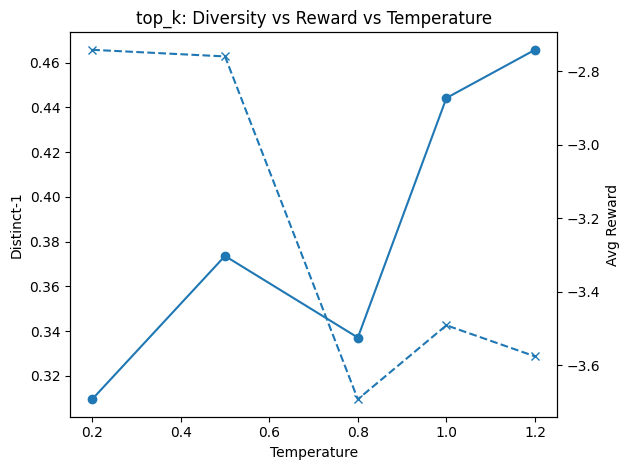

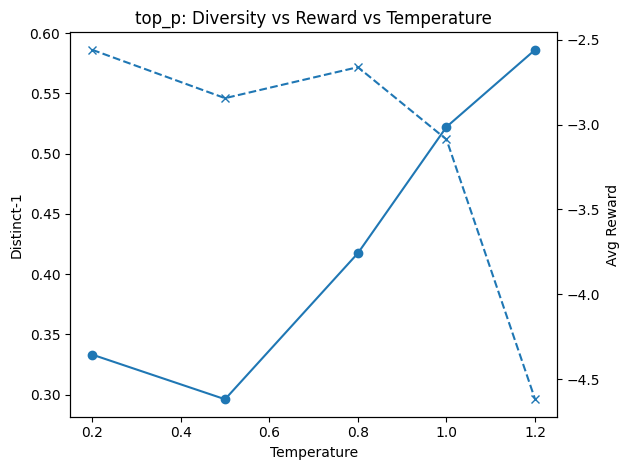

In [18]:
import pandas as pd

df_metrics = pd.DataFrame(all_metrics)
display(df_metrics)

def plot_diversity_quality(df: pd.DataFrame, strategy: str, n: int = 1):
    sub = df[df["strategy"] == strategy].sort_values("temperature")
    if sub.empty:
        print(f"No data for strategy {strategy}")
        return
    temps = sub["temperature"].tolist()
    # distinct_vals = sub[f"distinct_{n}").tolist() if f"distinct_{n}" in sub.columns else None
    distinct_vals = sub[f"distinct_{n}"].tolist() if f"distinct_{n}" in sub.columns else None
    reward_vals = sub["avg_reward"].tolist()

    fig, ax1 = plt.subplots()
    ax1.set_xlabel("Temperature")
    if distinct_vals is not None:
        ax1.plot(temps, distinct_vals, marker="o", label=f"Distinct-{n}")
        ax1.set_ylabel(f"Distinct-{n}")
    
    ax2 = ax1.twinx()
    ax2.plot(temps, reward_vals, marker="x", linestyle="--", label="Avg Reward")
    ax2.set_ylabel("Avg Reward")

    plt.title(f"{strategy}: Diversity vs Reward vs Temperature")
    fig.tight_layout()
    plt.show()

# Example plots for Top-K and Top-P, Distinct-1
for strat in ["top_k", "top_p"]:
    plot_diversity_quality(df_metrics, strategy=strat, n=1)

In [ ]:
import os, json
import pandas as pd


base_dir = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
output_dir = os.path.join(base_dir, "task1_outputs")
os.makedirs(output_dir, exist_ok=True)

# 1) Save df_metrics (diversity + reward per strategy/temperature)
try:
    df_metrics.to_csv(os.path.join(output_dir, "task1_df_metrics.csv"), index=False)
    print("Saved df_metrics to", os.path.join(output_dir, "task1_df_metrics.csv"))
except NameError:
    print("df_metrics is not defined yet. Run the metrics / plotting cell before autosave.")

# 2) Save across/within-prompt diversity summary
try:
    div_df = pd.DataFrame(diversity_summary)
    div_df.to_csv(os.path.join(output_dir, "task1_diversity_summary.csv"), index=False)
    print("Saved diversity_summary to", os.path.join(output_dir, "task1_diversity_summary.csv"))
except NameError:
    print("diversity_summary is not defined yet. Run the across/within diversity cell first.")

# 3) Save raw all_metrics JSON (same info as df_metrics but easier to re-process)
try:
    with open(os.path.join(output_dir, "task1_all_metrics.json"), "w") as f:
        json.dump(all_metrics, f, indent=2)
    print("Saved all_metrics JSON to", os.path.join(output_dir, "task1_all_metrics.json"))
except NameError:
    print("all_metrics is not defined yet. Run the grid evaluation cell first.")

print("Autosave complete. Files are in:")
print("  ", output_dir)

Saved df_metrics to /kaggle/working/task1_outputs/task1_df_metrics.csv
Saved diversity_summary to /kaggle/working/task1_outputs/task1_diversity_summary.csv
Saved all_metrics JSON to /kaggle/working/task1_outputs/task1_all_metrics.json
Autosave complete. Files are in:
   /kaggle/working/task1_outputs
